In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [10]:
import mlbench ## Usar o ambiente conda mlbench

In [24]:
def pdf(x, mu, sigma, n):
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

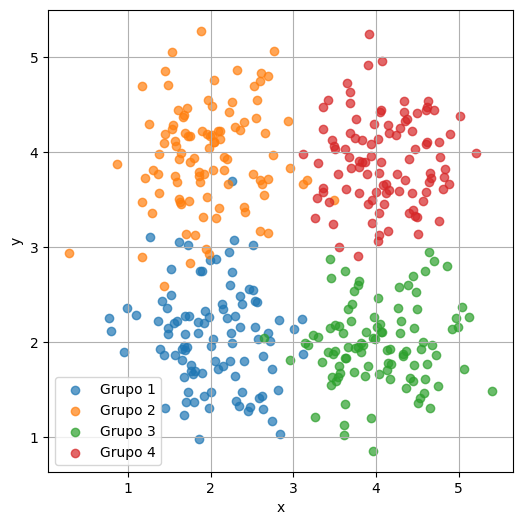

In [4]:
nc = 100
dimension = 2
std = 0.5

g1 = std*np.random.randn(nc, dimension) + np.array([2,2])
g2 = std*np.random.randn(nc, dimension) + np.array([2,4])
g3 = std*np.random.randn(nc, dimension) + np.array([4,2])
g4 = std*np.random.randn(nc, dimension) + np.array([4,4])

plt.figure(figsize=(6,6))
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
k1 = np.cov(g1.T)
k2 = np.cov(g2.T)
k3 = np.cov(g3.T)
k4 = np.cov(g4.T)

m1 = np.mean(g1, axis = 0)
m2 = np.mean(g2, axis = 0)
m3 = np.mean(g3, axis = 0)
m4 = np.mean(g4, axis = 0)


seqi = np.arange(0,6,0.1)
seqj = np.arange(0,6,0.1)

M = np.zeros(shape = (len(seqi),len(seqj)))

N1 = len(g1)
N2 = len(g2)
N3 = len(g3)
N4 = len(g4)

Nall = N1+N2+N3+N4

p1 = N1/Nall
p2 = N2/Nall
p3 = N3/Nall
p4 = N4/Nall

for ii, i in enumerate(seqi):       
    for jj, j in enumerate(seqj):  
        x = np.array([i, j])
        M[ii, jj] = (
            p1*pdf(x, m1, k1, dimension) +
            p2*pdf(x, m2, k2, dimension) +
            p3*pdf(x, m3, k3, dimension) +
            p4*pdf(x, m4, k4, dimension)
        )

/tmp/ipykernel_2292/4139100668.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(const * np.exp(expo))


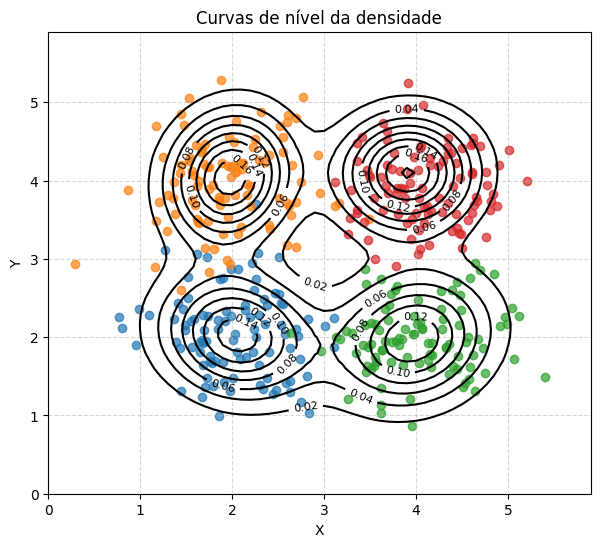

In [6]:
X, Y = np.meshgrid(seqi, seqj)
plt.figure(figsize=(7,6))
cs = plt.contour(X, Y, M, levels=10, colors="black")  
plt.clabel(cs, inline=True, fontsize=8) 
plt.scatter(g1[:,0], g1[:,1], label="Grupo 1", alpha=0.7)
plt.scatter(g2[:,0], g2[:,1], label="Grupo 2", alpha=0.7)
plt.scatter(g3[:,0], g3[:,1], label="Grupo 3", alpha=0.7)
plt.scatter(g4[:,0], g4[:,1], label="Grupo 4", alpha=0.7)
plt.title("Curvas de nível da densidade")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [7]:
fig = go.Figure(data=[go.Surface(z=M, x=X, y=Y, colorscale="Viridis")])
fig.update_layout(
    title="Densidade da mistura Gaussiana",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Densidade"
    )
)
fig.show() 

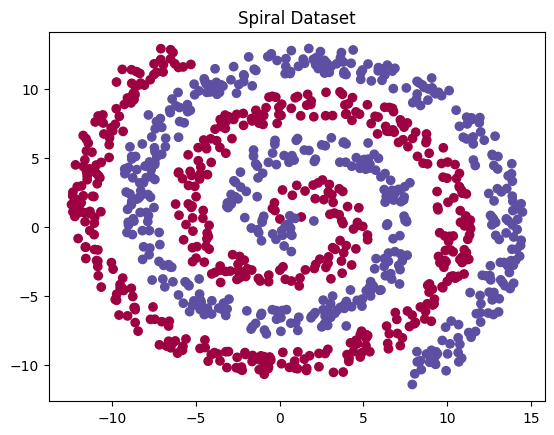

In [15]:
def generate_spiral(n_points, noise=0.5):
    n = np.sqrt(np.random.rand(n_points)) * 780 * (2 * np.pi) / 360
    d1x = -np.cos(n) * n + np.random.rand(n_points) * noise
    d1y = np.sin(n) * n + np.random.rand(n_points) * noise

    d2x = np.cos(n) * n + np.random.rand(n_points) * noise
    d2y = -np.sin(n) * n + np.random.rand(n_points) * noise

    X = np.concatenate((np.vstack((d1x, d1y)).T, np.vstack((d2x, d2y)).T))
    y = np.concatenate((np.zeros(n_points), np.ones(n_points)))

    return X, y

X, y = generate_spiral(500, noise=2)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.title("Spiral Dataset")
plt.show()


In [16]:
class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None

    def fit(self, X):
        if self.random_state:
            np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[random_idx]

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)

            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.n_clusters)])

            shift = np.linalg.norm(self.centroids - new_centroids)
            if shift < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels
        return self

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def predict(self, X):
        return self._assign_clusters(X)

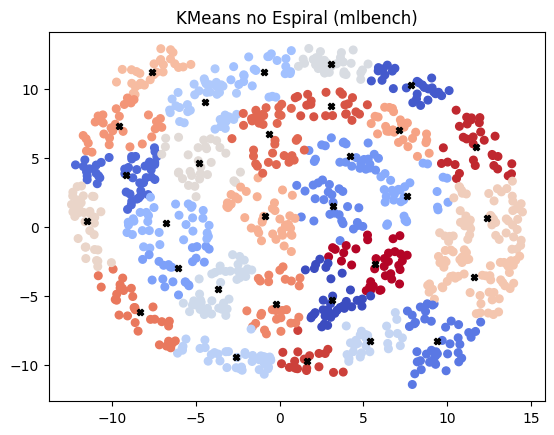

In [20]:
kmeans = KMeans(n_clusters=30, random_state=42)
kmeans.fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="coolwarm", s=30)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c="black", marker="X", s=20)
plt.title("KMeans no Espiral (mlbench)")
plt.show()


In [52]:
n_clusters = 30
n_features = X.shape[1]
n_samples = X.shape[0]

mus = []
sigmas = []
pis = []

for k in range(n_clusters):
    cluster_data = X[kmeans.labels_ == k]
    mu_k = cluster_data.mean(axis=0)
    sigma_k = np.cov(cluster_data, rowvar=False) + 1e-6*np.eye(n_features)  
    pi_k = cluster_data.shape[0] / n_samples
    
    mus.append(mu_k)
    sigmas.append(sigma_k)
    pis.append(pi_k)

mus = np.array(mus)
sigmas = np.array(sigmas)
pis = np.array(pis)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 900

In [29]:
max_iter = 10
tol = 1e-4
n_samples, n_features = X.shape

from tqdm import tqdm

for iteration in tqdm(range(max_iter)):
    gamma = np.zeros((n_samples, n_clusters))
    for i in range(n_samples):
        denom = sum([pis[k] * pdf(X[i], mus[k], sigmas[k], n_features) for k in range(n_clusters)])
        for k in range(n_clusters):
            gamma[i, k] = pis[k] * pdf(X[i], mus[k], sigmas[k], n_features) / denom

    N_k = gamma.sum(axis=0)
    for k in range(n_clusters):
        mus[k] = (gamma[:, k].reshape(-1,1) * X).sum(axis=0) / N_k[k]
        diff = X - mus[k]
        sigmas[k] = (gamma[:, k].reshape(-1,1) * diff).T @ diff / N_k[k] + 1e-6*np.eye(n_features)
        pis[k] = N_k[k] / n_samples

    if iteration > 0 and np.all(np.linalg.norm(mus - prev_mus, axis=1) < tol):
        break
    prev_mus = mus.copy()

print("Médias finais:", mus)
print("Pesos finais:", pis)


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_10857/4139100668.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(const * np.exp(expo))
100%|██████████| 10/10 [00:22<00:00,  2.26s/it]

Médias finais: [[  3.76079738  -5.58643766]
 [  8.65908108   9.80910639]
 [ -8.17489149   3.06056047]
 [ 10.13989624  -8.52861147]
 [  3.61980336   1.25931069]
 [  4.84344902   4.83791051]
 [ -5.55275098  -2.12725115]
 [  6.99985609   1.50382962]
 [ -2.4372866    2.82672347]
 [ -4.07329445   9.9555407 ]
 [ -5.84246666  11.7601294 ]
 [ -2.73916513  -9.29250179]
 [  6.13256711  -7.71854741]
 [ -4.46445448  -5.20445055]
 [  3.12736325  11.68014058]
 [ -4.79090929   4.29216532]
 [-11.43113039   2.77906925]
 [ 11.75599773   0.95868306]
 [ 11.35381807  -3.07669364]
 [ -8.79847447   9.7750135 ]
 [ -0.12251319   0.09392895]
 [  6.73340897   7.16353023]
 [ -6.9709796    7.35157817]
 [ -0.62112052  -6.6634344 ]
 [ -9.68510355  -4.32284602]
 [  0.45259904   4.33246977]
 [ -0.89612969   8.23499907]
 [ -0.67810006  -9.80868365]
 [ 12.55265051   4.96516842]
 [  2.05219927  -2.84812875]]
Pesos finais: [0.0416903  0.01763045 0.05694343 0.03704354 0.02853465 0.02247726
 0.01830642 0.0207151  0.03905374

In [35]:
import plotly.graph_objects as go

x = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
X_grid, Y_grid = np.meshgrid(x, y)
Z = np.zeros_like(X_grid)

def gmm_density(x, y, mus, sigmas, pis):
    point = np.array([x, y])
    total = 0
    n_features = 2
    for k in range(len(pis)):
        total += pis[k] * pdf(point, mus[k], sigmas[k], n_features)
    return total

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        Z[i, j] = gmm_density(X_grid[i, j], Y_grid[i, j], mus, sigmas, pis)

surface = go.Surface(x=X_grid, y=Y_grid, z=Z, colorscale='Viridis', opacity=0.7, name='GMM Density')

scatter_data = go.Scatter3d(
    x=X[:,0],
    y=X[:,1],
    z=np.zeros_like(X[:,0]),
    mode='markers',
    marker=dict(size=4, color='red'),
    name='Dados'
)

scatter_centers = go.Scatter3d(
    x=mus[:,0],
    y=mus[:,1],
    z=np.zeros_like(mus[:,0]),
    mode='markers',
    marker=dict(size=8, color='black', symbol='x'),
    name='Centros GMM'
)

fig = go.Figure(data=[surface, scatter_data, scatter_centers])
fig.update_layout(scene=dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Densidade'),
                  title='Superfície de densidade GMM após KMeans')

fig.show()


/tmp/ipykernel_10857/4139100668.py:5: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [43]:
X,y = generate_spiral(n_points=500, noise= 2)

In [45]:
y.shape

(1000,)

In [47]:
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)
aris = []

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    kmeans = KMeans(n_clusters=30, random_state=42)
    kmeans.fit(X_train)
    
    y_pred = kmeans.predict(X_test)
    ari = adjusted_rand_score(y_test, y_pred)
    aris.append(ari)
    
    print(f"Fold {fold}, ARI: {ari:.3f}")

print(f"\nARI médio: {np.mean(aris):.3f}")


Fold 1, ARI: 0.026
Fold 2, ARI: 0.023
Fold 3, ARI: 0.016
Fold 4, ARI: 0.052
Fold 5, ARI: 0.032
Fold 6, ARI: 0.036
Fold 7, ARI: 0.019
Fold 8, ARI: 0.016
Fold 9, ARI: 0.032
Fold 10, ARI: 0.035

ARI médio: 0.029


In [51]:
fold = kf.split(X)
fold

<generator object _BaseKFold.split at 0x7de270685820>